# Caderno 3 - Análise da anotação por LLM

## 1. Arquivos de entrada

In [1]:
ARQUIVO_HUMAN_EVALS = './dados/outputs/0 - qrel - docs - query - raw_human_eval/raw_human_eval.csv'
PASTA_LLM_EVAL = './dados/outputs/2 - llm evals/'

## 2. Dataframes com as avaliações

In [2]:
import pandas as pd
import glob

# Carrega as avaliações humanas
df_human_evals = pd.read_csv(ARQUIVO_HUMAN_EVALS)

# Carrega as avaliações com LLM
arquivos_csv = glob.glob(f"{PASTA_LLM_EVAL}/*.csv")
df_llm_evals = pd.concat(
    (pd.read_csv(arquivo) for arquivo in arquivos_csv),
    ignore_index=True
)
# Para df_llm_evals ficar com o mesmo formato de df_human_evals, 
# vamos definir o avaliador como o conjunto MODELO e PROMPT
# e selecionar só as colunas que importam
df_llm_evals["USUARIO_AVALIADOR"] = (
    df_llm_evals["MODELO"].astype(str) + "_" +
    df_llm_evals["PROMPT"].astype(str)
)
df_llm_evals = df_llm_evals[["QUERY_KEY", "DOC_KEY", "AVALIACAO", "USUARIO_AVALIADOR"]]

# Cria um df_all_evals com a concatenação de df_human_evals e df_llm_evals
df_all_evals = pd.concat(
    [df_human_evals, df_llm_evals],
    ignore_index=True
)

## 3. Análise das anotações

### 3.1. Distribuição de labels por anotador


=== Label distribution (counts) per annotator ===
AVALIACAO                          0     1     2  Total
USUARIO_AVALIADOR                                      
A_1                              536    66   203    805
A_2                              477    80   156    713
A_3                              461   137   207    805
A_4                              451   166   108    725
deepseek-chat_simple             420   237   155    812
deepseek-chat_cot                397   208   207    812
gpt-5-mini-2025-08-07_simple     215   332   265    812
gpt-5-mini-2025-08-07_cot        216   345   251    812
sabiazinho-4-2026-01-06_simple   290   184   338    812
sabiazinho-4-2026-01-06_cot      209   306   297    812
Total                           3672  2061  2187   7920

=== Label distribution (%) per annotator ===
AVALIACAO                          0     1     2
USUARIO_AVALIADOR                               
A_1                             66.6   8.2  25.2
A_2                         

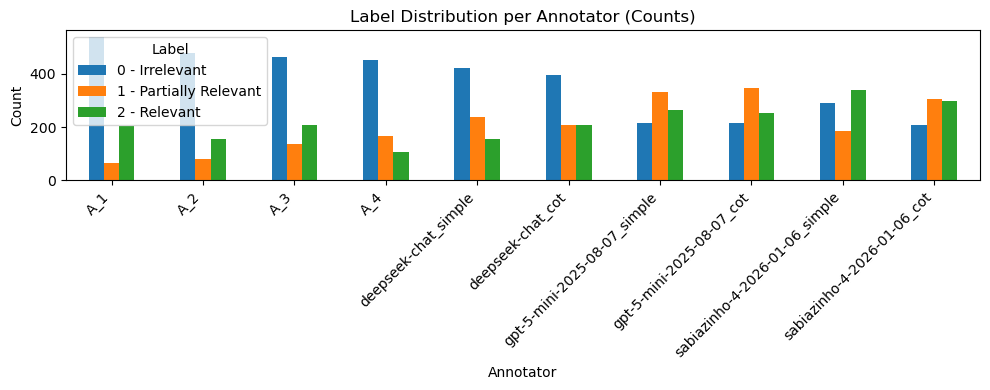

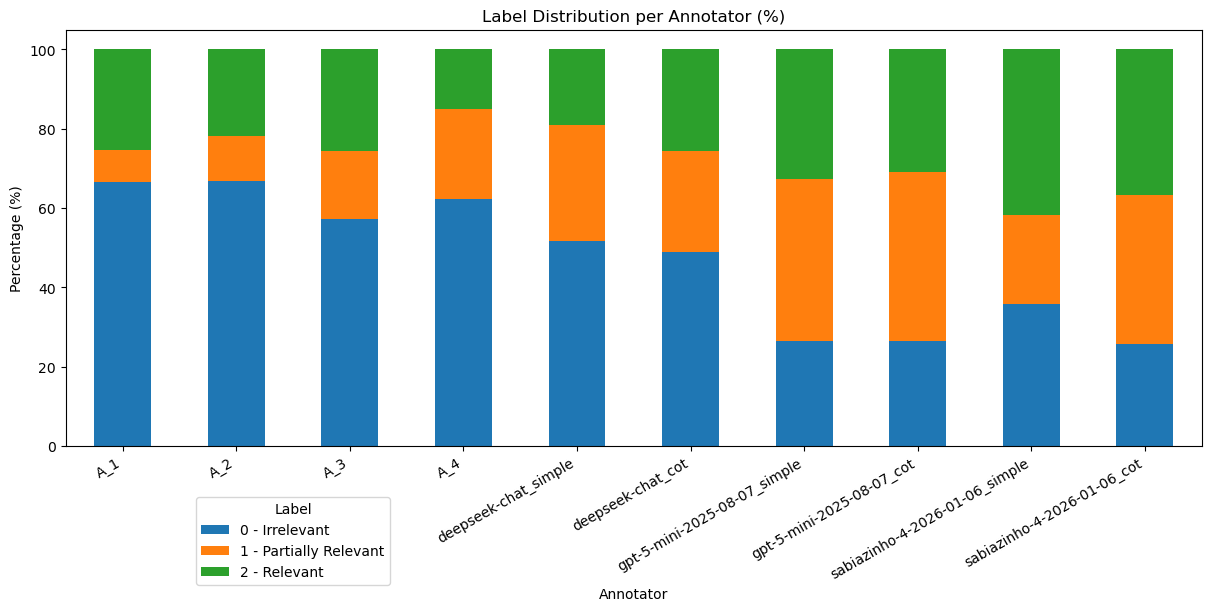

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LEVEL 1 — Individual annotator behavior
# Fixed annotator order: A_1, A_2, A_3, A_4
# ============================================================

df = df_all_evals.copy()

# Fixed annotator order
eval_order = ["A_1", "A_2", "A_3", "A_4", "deepseek-chat_simple", "deepseek-chat_cot", "gpt-5-mini-2025-08-07_simple", "gpt-5-mini-2025-08-07_cot", "sabiazinho-4-2026-01-06_simple", "sabiazinho-4-2026-01-06_cot"]

# ============================================================
# 1.1 Tables: label distribution per annotator
# ============================================================

# Absolute counts of labels (0/1/2)
dist_counts = (
    df.groupby(["USUARIO_AVALIADOR", "AVALIACAO"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=eval_order, fill_value=0)
      .reindex(columns=[0, 1, 2], fill_value=0)
)

# ---- Add row totals (Total per annotator)
dist_counts["Total"] = dist_counts.sum(axis=1)

# ---- Add column totals (Total per label + grand total)
column_totals = dist_counts.sum(axis=0)
dist_counts.loc["Total"] = column_totals

# Percentages (computed BEFORE adding totals row)
dist_pct = (
    df.groupby(["USUARIO_AVALIADOR", "AVALIACAO"])
      .size()
      .unstack(fill_value=0)
      .reindex(index=eval_order, fill_value=0)
      .reindex(columns=[0, 1, 2], fill_value=0)
)

dist_pct = dist_pct.div(dist_pct.sum(axis=1), axis=0)

# ============================================================
# PRINT TABLES
# ============================================================

print("\n=== Label distribution (counts) per annotator ===")
print(dist_counts)

print("\n=== Label distribution (%) per annotator ===")
print((dist_pct * 100).round(1))

# ============================================================
# PLOTS (unchanged)
# ============================================================

# Remove the totals row for plotting
plot_counts = dist_counts.loc[eval_order, [0, 1, 2]]
plot_pct = dist_pct.loc[eval_order, [0, 1, 2]]

label_map = {
    0: "0 - Irrelevant",
    1: "1 - Partially Relevant",
    2: "2 - Relevant"
}

# ---------------------------
# 1) Grouped bar chart (counts)
# ---------------------------
ax = plot_counts.plot(kind="bar", figsize=(10, 4))
ax.set_title("Label Distribution per Annotator (Counts)")
ax.set_xlabel("Annotator")
ax.set_ylabel("Count")

# Atualiza legenda
handles, labels = ax.get_legend_handles_labels()
labels = [label_map[int(l)] for l in labels]
ax.legend(handles, labels, title="Label", ncol=1)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# ---------------------------
# 2) Stacked bar chart (percentages)
# ---------------------------
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)

(plot_pct * 100).plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_title("Label Distribution per Annotator (%)")
ax.set_xlabel("Annotator")
ax.set_ylabel("Percentage (%)")

# Atualiza legenda
handles, labels = ax.get_legend_handles_labels()
labels = [label_map[int(l)] for l in labels]

ax.legend(
    handles,
    labels,
    title="Label",
    loc="lower center",
    bbox_to_anchor=(0.2, -0.35),
    ncol=1
)

# Inclina rótulos do eixo x
ax.tick_params(axis="x", rotation=30)
for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

#plt.savefig("label_distribution_percentage_human_and_llm.png", dpi=300, bbox_inches="tight")
plt.show()



In [4]:
df_sabiazinho_simple = df_llm_evals[
    df_llm_evals["USUARIO_AVALIADOR"] == "sabiazinho-4-2026-01-06_simple"
]

print(df_sabiazinho_simple.AVALIACAO.unique())

[2 0 1]


In [5]:
df_menos1

NameError: name 'df_menos1' is not defined